# Simulating and Localizing Multi-Source EEG Activity — Multiple Runs

This tutorial extends the **single-run** simulation/localization workflow presented in the
["Simulating and Localizing Multi-Source EEG Activity with MVPURE_py tutorial"](https://julia-jurkowska.github.io/mvpure-tools/tutorials/simulating_and_localizing_multi-source_EEG_activity_with_MVPURE_py.html).

The simulation, forward modeling, preprocessing, MVPURE_py localization, and LCMV comparison are
essentially the same as in that tutorial. We therefore assume that you already know that workflow
and focus on the new part:

> **How to repeat the complete experiment many times and aggregate the results.**

Repeating the experiment is important because the source locations are randomly sampled in every
run. A single run therefore gives only one realization of the experiment, whereas multiple runs
allow us to characterize the distribution and variability of localization performance.

The notebook follows the structure of the original script, but separates the workflow into:

1. one-time setup and data loading,
2. a repeated simulation/localization loop,
3. collection of results from every run,
4. aggregation and visualization of the results,

For the details of the individual simulation steps, see the previous tutorial linked above.

In [1]:
import os
import time
import pickle

import numpy as np
import matplotlib.pyplot as plt
import mne

from mvpure_py import simulation, utils

In [2]:
# ------------------------------------------------------------
# HELPER VISUALIZATION FUNCTION
# ------------------------------------------------------------
def violin_plot_from_results(
        ax,
        snr_dict: dict,
        results_key: str,
        title: str | None = None,
        xlabel: str ="Rank",
        ylabel: str | None = None,
        color: str = "indigo",
        include_lcmv: bool = False,
        lcmv_color: str = "crimson",
        show_means: bool = True,
):
    """
    Create a violin plot of the results stored in `snr_dict`.
    """
    # Collect distributions for each rank
    data = [
        results[results_key]
        for _, results in snr_dict['by_rank'].items()
    ]

    labels = [str(i) for i in range(1, len(data) + 1)]

    if include_lcmv:
        if results_key == "n_correctly_localized":
            lcmv_key = "lcmv_n_correctly_localized"
        elif results_key == "mean_error":
            lcmv_key = "lcmv_mean_error"
        else:
            raise ValueError(f"Unsupported results_key: {results_key}")

        data.append(snr_dict[lcmv_key])
        labels.append("LCMV-NAI")

    positions = np.arange(1, len(data) + 1)

    vp = ax.violinplot(
        data,
        positions=positions,
        showmeans=show_means,
        showmedians=False,
        showextrema=False,
    )

    # Color all violins
    for i, body in enumerate(vp['bodies']):
        if include_lcmv and i == len(data) - 1:
            body.set_facecolor(lcmv_color)
        else:
            body.set_facecolor(color)

        body.set_edgecolor('black')
        body.set_alpha(0.7)

    # Optionally customize mean lines
    if show_means:
        vp['cmeans'].set_color('black')
        vp['cmeans'].set_linewidth(2)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontdict={"fontsize": 11})
    xticklabels = ax.get_xticklabels()
    xticklabels[-1].set_rotation(45)
    xticklabels[-1].set_ha('right')

    ax.grid(True)
    ax.set_title(title, fontdict={"fontsize": 13})

    if xlabel is not None:
        ax.set_xlabel(xlabel, fontdict={"fontsize": 12})
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontdict={"fontsize": 12})

## 1. Experiment configuration

Most parameters below are inherited directly from the original simulation script.

The important new parameter is `N_RUNS`: instead of generating one dataset and evaluating it once,
we repeat the experiment `N_RUNS` times.

For a quick notebook run, use a small value such as `N_RUNS = 10`. Once the workflow is verified, ``N_RUNS`` can be increased to the desired number of repetitions, e.g. ``100`` or ``1000``.

The parameters defining the simulated sources, their activity, and the sensor-level noise remain fixed across runs. What changes between runs is the random realization of the simulated experiment, including the selected source locations and simulated activity.

In [3]:
labels_to_use = [
    "cuneus-lh",
    "cuneus-rh",
    "lateraloccipital-lh",
    "lateraloccipital-rh",
    "inferiorparietal-lh",
    "inferiorparietal-rh",
    "superiorparietal-lh",
    "superiorparietal-rh",
    "superiortemporal-lh",
    "superiortemporal-rh",
    "supramarginal-lh",
    "supramarginal-rh",
    "superiorfrontal-lh",
    "superiorfrontal-rh",
    "insula-lh",
    "insula-rh",
    "caudalanteriorcingulate-lh",
    "caudalanteriorcingulate-rh"
]

labels_to_use_poststimuli = [
    'lateraloccipital-rh',
    'superiorfrontal-rh',
    'caudalanteriorcingulate-lh',
    'caudalmiddlefrontal-lh',
    'lateraloccipital-lh'
]

SUBJECT = "sample_subject"
SUBJECTS_DIR = "subjects"

mne.set_config("SUBJECTS_DIR", SUBJECTS_DIR)

N_VERTICES_PER_BG_LABEL = 1
N_VERTICES_PER_ACTIVITY_LABEL = 1
N_EPOCHS = 100

ERP_FACTOR = 15e-9
ORDER_BG = 7
ORDER = 3
TARGET_STD_BG = 15e-9
TARGET_STD = 15e-9
COUPLING_BG = 0.5
COUPLING = 0.8
NOISE_BG = 1.0
NOISE = 1.0
GAUSSIAN_FILTER_SIGMA_BG = 3
GAUSSIAN_FILTER_SIGMA = 3
N_DOMINANT_EIGVALS = 2
NOISE_FACTOR_SENSORS = 0.3

FIND_CLOSE = False

# NEW: number of independent repetitions of the experiment.
# Use 10 for a quick test; use larger number e.g., 1000 for the full experiment.
N_RUNS = 10

SNR_DB = 1.0

## 2. Load the data and forward model once

These objects do not change between runs, so there is no reason to load them inside the loop.

We use the same sample-subject epoched data and forward solution as in the previous tutorial.
The epochs provide the sampling frequency, timing, channel information, and other MNE metadata;
the forward solution provides the lead field and source-space geometry.

In [4]:
print("Loading data...")

epoched = mne.read_epochs(
    os.path.join(
        SUBJECTS_DIR,
        SUBJECT,
        "_eeg",
        "_pre",
        f"{SUBJECT}_oddball-epo.fif",
    )
)

forward_path = os.path.join(
    SUBJECTS_DIR,
    SUBJECT,
    "forward",
    f"{SUBJECT}_ico4-fwd.fif",
)

fwd_vector = mne.read_forward_solution(forward_path)

fwd = mne.convert_forward_solution(
    fwd_vector,
    surf_ori=True,
    force_fixed=True,
    use_cps=True,
)

leadfield = fwd["sol"]["data"]
src = fwd["src"]

sfreq = epoched.info["sfreq"]
tmin, tmax = epoched.tmin, 0.25
times = np.arange(tmin, tmax, 1 / sfreq)
n_times = len(times)

post_mask = (times >= 0.05) & (times <= 0.2)

print(f"Sampling frequency: {sfreq:.2f} Hz")
print(f"Number of time points: {n_times}")
print(f"Number of sources in forward model: {leadfield.shape[1]}")

Loading data...
Reading /Volumes/UMK/oddball/subjects/sample_subject/_eeg/_pre/sample_subject_oddball-epo.fif ...
    Found the data of interest:
        t =    -199.22 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
621 matching events found
No baseline correction applied
0 projection items activated
Reading forward solution from /Volumes/UMK/oddball/subjects/sample_subject/forward/sample_subject_ico4-fwd.fif...
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read EEG forward solution (5124 sources, 128 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
    No patch info available. The standard source space normals will be employed in the rotation to the local surface coordinates....
    Changing to fixed-orientation forward solution with surface-based s

## 3. What changes between runs?

The key stochastic step is the selection of source vertices.

For every run we call `simulation.get_random_vertices(...)` again. This means that the background
and post-stimulus sources are re-sampled, subject to the same anatomical constraints.

Everything downstream is then recomputed for that realization:

`random vertices → source simulation → sensor simulation → preprocessing → covariance → localization → evaluation`

This is the main conceptual difference from the previous tutorial.

## 4. Store results from all runs

Instead of keeping only the result of the current run, we append the relevant metrics to `FULL_RESULTS`.

Results are stored separately for each tested rank. For every rank we keep:

- number of correctly localized sources,
- mean localization error.

We also store, for each run:

- the rank(s) with the smallest mean error,
- the rank(s) with the largest number of correctly localized sources,
- the corresponding LCMV metrics.

Keeping the per-run values is preferable to storing only an average: it lets us inspect variability, compare methods, and perform additional analyses later without repeating the simulations.

In [5]:
FULL_RESULTS = {
    "by_rank": {},
    "best_rank_mse": [],
    "best_rank_n_locs": [],
    "lcmv_n_correctly_localized": [],
    "lcmv_mean_error": [],
}

## 5. Run the complete experiment repeatedly

The code below is close to the original single-run implementation.

The main structural change is that the whole simulation-localization block is inside:

```python
for n in range(N_RUNS):
    ...
```

The source locations are sampled on every iteration, so each iteration is an independent
realization of the same experimental condition.

In [6]:
start = time.time()

for n in range(N_RUNS):
    print(f"==== RUN {n + 1}/{N_RUNS} ====")

    # ------------------------------------------------------------
    # 1. Random source locations
    # ------------------------------------------------------------
    labels_info = simulation.get_random_vertices(
        n_vertices_per_label_bg=N_VERTICES_PER_BG_LABEL,
        n_vertices_per_poststimuli_label=N_VERTICES_PER_ACTIVITY_LABEL,
        noise_labels=labels_to_use,
        poststimuli_labels=labels_to_use_poststimuli,
        subject=SUBJECT,
        subjects_dir=SUBJECTS_DIR,
        src=src,
        find_close=FIND_CLOSE
    )

    noise_vertices, poststimuli_vertices = simulation.split_vertices(
        labels_info,
        labels_to_use_poststimuli,
    )

    leadfield_subset_indices_noise, lh_vert_to_lf_noise, rh_vert_to_lf_noise = (
        utils.translation.transform_vertices_to_leadfield_indices(
            vertices=noise_vertices,
            src=src,
            hemi="both",
            include_mapping=True,
        )
    )

    leadfield_subset_poststimuli_indices, lh_vert_to_lf_stimuli, rh_vert_to_lf_stimuli = (
        utils.translation.transform_vertices_to_leadfield_indices(
            vertices=poststimuli_vertices,
            src=src,
            hemi="both",
            include_mapping=True,
        )
    )

    leadfield_subset_indices = np.unique(
        np.concatenate(
            (
                leadfield_subset_indices_noise,
                leadfield_subset_poststimuli_indices,
            )
        )
    )

    leadfield_to_label_mapping = simulation.assign_label_to_leadfield_index(
        labels_info=labels_info,
        lh_vert_to_lf=lh_vert_to_lf_noise | lh_vert_to_lf_stimuli,
        rh_vert_to_lf=rh_vert_to_lf_noise | rh_vert_to_lf_stimuli,
    )

    # ------------------------------------------------------------
    # 2. Simulate source activity
    # ------------------------------------------------------------
    X_epochs = simulation.simulate_source_epochs(
        n_epochs=N_EPOCHS,
        lf_subset_indices=leadfield_subset_indices,
        n_times=n_times,
        bg_lf_subset_indices=leadfield_subset_indices_noise,
        poststimuli_mask=post_mask,
        poststimuli_lf_subset_indices=leadfield_subset_poststimuli_indices,
        lf_to_label=leadfield_to_label_mapping,
        sfreq=sfreq,
        erp_factor=ERP_FACTOR,
        snr_db=SNR_DB,
        order_bg=ORDER_BG,
        order=ORDER,
        target_std_bg=TARGET_STD_BG,
        target_std=TARGET_STD,
        coupling_bg=COUPLING_BG,
        coupling=COUPLING,
        noise_bg=NOISE_BG,
        noise=NOISE,
        gaussian_filter_sigma=GAUSSIAN_FILTER_SIGMA,
        gaussian_filter_sigma_bg=GAUSSIAN_FILTER_SIGMA_BG,
        n_dominant_eigvals=N_DOMINANT_EIGVALS,
        seed=n,
    )

    # ------------------------------------------------------------
    # 3. Project source activity to sensors
    # ------------------------------------------------------------
    sim_epochs = simulation.simulate_sensor_epochs(
        X_epochs=X_epochs,
        leadfield=leadfield,
        lf_subset_indices=leadfield_subset_indices,
        src=src,
        tmin=tmin,
        sfreq=sfreq,
        noise_factor=NOISE_FACTOR_SENSORS,
        info=epoched.info,
    )

    # ------------------------------------------------------------
    # 4. Preprocessing
    # ------------------------------------------------------------
    sim_epochs = sim_epochs.filter(
        l_freq=1,
        h_freq=45,
        method="iir",
    )

    noise_cov = mne.compute_covariance(
        sim_epochs,
        tmin=-0.2,
        tmax=0,
        method="empirical",
    )

    data_cov = mne.compute_covariance(
        sim_epochs,
        tmin=0.05,
        tmax=0.2,
        method="empirical",
    )

    sim_epochs.set_eeg_reference("average", projection=True)
    sim_epochs.apply_proj()
    sim_evoked = sim_epochs.average()
    sim_evoked = sim_evoked.copy().crop(
        tmin=0.05,
        tmax=0.2
    )

    # ------------------------------------------------------------
    # 5. MVPURE localization for every rank
    # ------------------------------------------------------------
    locs_results_summary = simulation.evaluate_localization_for_each_rank(
        subject=SUBJECT,
        subjects_dir=SUBJECTS_DIR,
        n_sources=len(labels_to_use_poststimuli) * N_VERTICES_PER_ACTIVITY_LABEL,
        R=data_cov.data,
        N=noise_cov.data,
        forward=fwd,
        true_vertices=poststimuli_vertices,
        localizer_to_use="mai_mvp",
        plot_sum_error_by_rank=False,
        plot_correct_sources_by_rank=False,
        plot_mean_error_by_rank=False,
        show_progress=False,
    )

    mse = []
    n_corr_locs = []

    for rank, items in locs_results_summary.items():
        if rank not in FULL_RESULTS["by_rank"]:
            FULL_RESULTS["by_rank"][rank] = {
                "n_correctly_localized": [],
                "mean_error": [],
            }

        mse.append(items["error_info"]["mean_error"])
        n_corr_locs.append(items["n_correctly_localized"])

        FULL_RESULTS["by_rank"][rank]["n_correctly_localized"].append(
            items["n_correctly_localized"]
        )
        FULL_RESULTS["by_rank"][rank]["mean_error"].append(
            items["error_info"]["mean_error"]
        )

    FULL_RESULTS["best_rank_mse"].append(
        [i + 1 for i, x in enumerate(mse) if x == min(mse)]
    )

    FULL_RESULTS["best_rank_n_locs"].append(
        [i + 1 for i, x in enumerate(n_corr_locs) if x == max(n_corr_locs)]
    )

    # ------------------------------------------------------------
    # 6. LCMV comparison
    # ------------------------------------------------------------
    (
        lcmv_top_vertices,
        lcmv_n_correctly_localized,
        lcmv_error_info,
    ) = simulation.compare_with_strongest_sources_lcmv(
        signal=sim_evoked,
        n_sources=len(labels_to_use_poststimuli) * N_VERTICES_PER_ACTIVITY_LABEL,
        true_vertices=poststimuli_vertices,
        forward=fwd,
        R=data_cov,
        N=noise_cov,
        reg=0.05,
        pick_ori=None,
    )

    FULL_RESULTS["lcmv_n_correctly_localized"].append(
        lcmv_n_correctly_localized
    )
    FULL_RESULTS["lcmv_mean_error"].append(
        lcmv_error_info["mean_error"]
    )

elapsed = time.time() - start
print(f"Elapsed time: {elapsed:.2f} s ({elapsed / 60:.2f} min)")

==== RUN 1/10 ====
Reading labels from parcellation...
   read 0 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/lh.aparc.annot
   read 1 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/rh.aparc.annot
Reading labels from parcellation...
   read 1 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/lh.aparc.annot
   read 0 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/rh.aparc.annot
Reading labels from parcellation...
   read 0 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/lh.aparc.annot
   read 1 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/rh.aparc.annot
Reading labels from parcellation...
   read 1 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/lh.aparc.annot
   read 0 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/rh.aparc.annot
Reading labels from parcellation...
   read 1 labels from /Volumes/UMK/oddball/subjects/sample_subject/label/lh.aparc.annot
   read 0

## 6. Inspect the raw multi-run result structure

`FULL_RESULTS["by_rank"][rank]` contains set of results per run.

This is the important difference from a single-run analysis: instead of one localization  error
for a rank, we now have a distribution of errors across independent realizations.

In [7]:
print("Ranks evaluated:", sorted(FULL_RESULTS["by_rank"].keys()))

for rank in sorted(FULL_RESULTS["by_rank"]):
    n_runs = len(FULL_RESULTS["by_rank"][rank]["mean_error"])
    print(f"Rank {rank}: {n_runs} runs")

print(f"Number of LCMV runs: {len(FULL_RESULTS['lcmv_mean_error'])}")

Ranks evaluated: ['rank_1', 'rank_2', 'rank_3', 'rank_4', 'rank_5']
Rank rank_1: 10 runs
Rank rank_2: 10 runs
Rank rank_3: 10 runs
Rank rank_4: 10 runs
Rank rank_5: 10 runs
Number of LCMV runs: 10


## 7. Aggregate performance across runs

For each rank we can now calculate summary statistics such as:

- mean localization error,
- median localization error,
- standard deviation,
- mean number of correctly localized sources.

The mean summarizes overall performance, while the standard deviation shows how sensitive the
method is to the particular random source configuration.

In [8]:
rank_summary = {}

for rank, result in sorted(FULL_RESULTS["by_rank"].items()):
    errors = np.asarray(result["mean_error"], dtype=float)
    n_correct = np.asarray(result["n_correctly_localized"], dtype=float)

    rank_summary[rank] = {
        "mean_error": np.mean(errors),
        "median_error": np.median(errors),
        "std_error": np.std(errors),
        "mean_n_correct": np.mean(n_correct),
        "std_n_correct": np.std(n_correct),
    }

for rank, summary in rank_summary.items():
    print(
        f"Rank {rank}: "
        f"mean error = {summary['mean_error']:.3f}, "
        f"median = {summary['median_error']:.3f}, "
        f"SD = {summary['std_error']:.3f}, "
        f"mean correctly localized = {summary['mean_n_correct']:.2f}"
    )

Rank rank_1: mean error = 24.696, median = 24.230, SD = 7.313, mean correctly localized = 2.50
Rank rank_2: mean error = 19.229, median = 19.832, SD = 9.093, mean correctly localized = 3.30
Rank rank_3: mean error = 21.782, median = 23.054, SD = 8.687, mean correctly localized = 3.00
Rank rank_4: mean error = 20.682, median = 18.413, SD = 6.652, mean correctly localized = 3.00
Rank rank_5: mean error = 20.354, median = 17.631, SD = 10.935, mean correctly localized = 3.20


## 8. Localization error as a function of rank

Each violin represents the distribution obtained from the repeated simulations. This makes it possible to see not only the typical localization error for a given rank, but also the variability across different source configurations.

The LCMV-NAI result is shown alongside the MVPURE ranks for comparison.

Lower localization error indicates better performance.

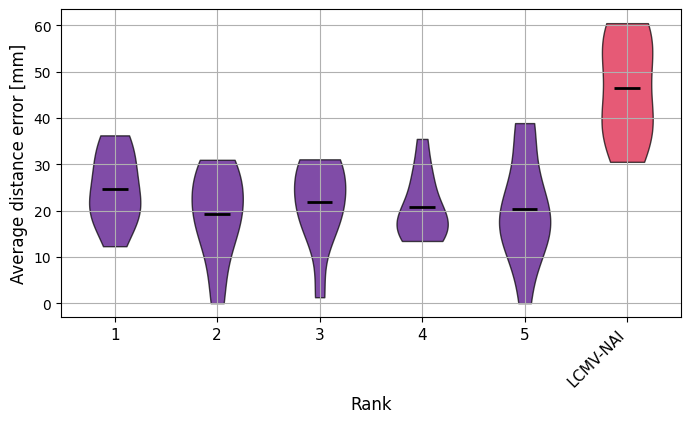

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(8, 4), sharey=True, sharex=True)
violin_plot_from_results(axs,
                         FULL_RESULTS,
                         results_key="mean_error",
                         ylabel="Average distance error [mm]",
                         xlabel="Rank", title=None, include_lcmv=True)
plt.show()

We can perform the same analysis for the number of correctly localized sources.

The violin plot shows the distribution of this measure across runs for each MVPURE rank and for LCMV-NAI.

Here, larger values indicate better localization performance.

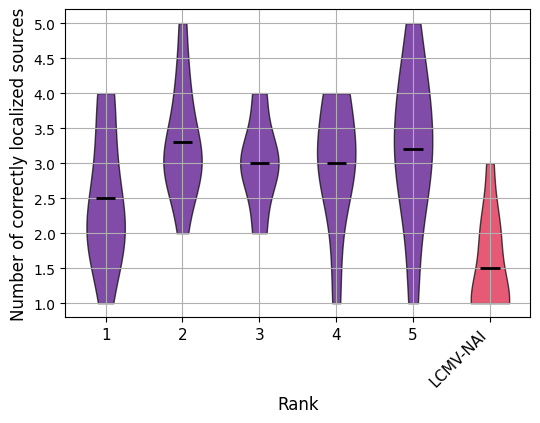

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(6, 4), sharey=True, sharex=True)
violin_plot_from_results(axs,
                         FULL_RESULTS,
                         results_key="n_correctly_localized",
                         ylabel="Number of correctly localized sources",
                         xlabel="Rank", title=None, include_lcmv=True)
plt.show()

## 9. Save the results

After all runs have finished, ``FULL_RESULTS`` contains the complete set of results from the experiment.

We can save this dictionary as a Python pickle (``.pkl``) file. This allows us to perform the analysis later without running the computationally expensive simulations again.

For example:

In [ ]:
OUTPUT_PATH = "synthetic_results.pkl"

with open(OUTPUT_PATH, "wb") as f:
    pickle.dump(FULL_RESULTS, f)

print(f"Results saved to: {OUTPUT_PATH}")

## 11. Repeating the experiment for multiple SNR values

The same framework can also be used to evaluate localization performance at multiple signal-to-noise ratios.

Instead of running the experiment for a single SNR value, we can define a list of values, for example:

```python
SNRS = [3, 5, 7, 10]
```

The experiment can then be wrapped in an additional loop over `SNRS`:

```python
for SNR_DB in SNRS:
    for n in range(N_RUNS):
        ...
```

In this setup, `N_RUNS` independent simulations are performed for each SNR value.

The results can be stored separately for each SNR, for example in a dictionary:

```python
ALL_RESULTS = {}

for SNR_DB in SNRS:
    # initialize results for this SNR
    ...
    ALL_RESULTS[SNR_DB] = FULL_RESULTS
```

This makes it possible to compare how MVPURE localization performance changes as the SNR decreases or increases.

For a multi-SNR experiment, it is useful to save the results for each SNR separately, or save the complete `ALL_RESULTS` dictionary in a single `.pkl` file.


## Summary

The simulation and localization pipeline is intentionally almost unchanged from the previous
tutorial. The new element is the **experimental repetition layer**:

```text
                 ┌─ run 1 ─┐
                 ├─ run 2 ─┤
same parameters ─┼─ run 3 ─┼─→ aggregate results → distributions / summaries
                 ├─  ...  ─┤
                 └─ run N ─┘
```

Each run independently samples source locations and generates new simulated data. The resulting
per-run metrics are retained, which allows us to quantify both average performance and variability.

For the full experiment, increase `N_RUNS` from the tutorial value to ``100`` or ``1000``. The resulting `FULL_RESULTS` object can then be analyzed without rerunning the simulation.